In [1]:

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
import QMIX
import buffer
import pong
from easydict import EasyDict
import jax
import jax.numpy as jnp
from physics import *
from util import *
config = EasyDict()
config.dt = 0.05
config.percent = 0.2
config.slop = 0.01
config.restitution = 1.0
config.state_dim = 13
config.action_dim = 2
config.batch_size = 256
config.episode_length = 1000
config.sync_period = 100
config.n_agents = 2
config.embed_dim = 64
config.layer_dim = 256
config.tau = 0.005
config.gamma = 0.99
config.lr = 3e-4
config.seed = 0

config.ppo_epochs = 10
config.clip_ratio = 0.05
config.entropy_coef = 0.0001

pong_env = pong.Pong(config)

config.lamda = 0.95
config.n_env = 100
config.clip_value = 100000.0

In [2]:
v_reset = jax.vmap(pong_env.reset)
v_step = jax.vmap(pong_env.step, in_axes=(0, 0, 0))


In [3]:
import tensorflow_probability.substrates.jax as tfp
tfd = tfp.distributions
tfb = tfp.bijectors


def sample_action(policy, states, key):
    logits = policy(states)
    sample = tfd.Categorical(logits = logits).sample(seed = key)
    log_probs = tfd.Categorical(logits = logits).log_prob(sample)
    return sample, log_probs

import MAPPO

train_state = MAPPO.init_train_state(config)

from flax import nnx

NetworkState = namedtuple('NetworkState', ['graphdef', 'state'])
TrainState = namedtuple('TrainState', ['pi1_state', 'pi2_state', 'value_state', 'key'])
Model = namedtuple('Model', ['network', 'optimizer'])

def get_model(state: NetworkState) -> Model:
    network, optimizer = nnx.merge(state.graphdef, state.state)
    return network, optimizer


def sample_action(policy, states, key):
    logits = policy(states)
    sample = tfd.Categorical(logits = logits).sample(seed = key)
    log_probs = tfd.Categorical(logits = logits).log_prob(sample)
    return sample, log_probs


2025-03-20 12:38:28.876628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1742474308.888434 4021042 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1742474308.892165 4021042 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
key = train_state.key
        
pi1, pi1_optimizer = get_model(train_state.pi1_state)
pi2, pi2_optimizer = get_model(train_state.pi2_state)
value, value_optimizer = get_model(train_state.value_state)

key, env_reset_key = jax.random.split(key, 2)

In [5]:
def rollout(train_state):

    key = train_state.key
        
    pi1, pi1_optimizer = get_model(train_state.pi1_state)
    pi2, pi2_optimizer = get_model(train_state.pi2_state)
    value, value_optimizer = get_model(train_state.value_state)

    def rollout_(carry, _):
        (env_state, obs, key) = carry
        key1, key2, key3, key4, env_reset_key, key = jax.random.split(key, 6)
        
        def get_action(obs, key):
            return jax.random.randint(key, (obs.shape[0], ), 0, 2), jnp.array(0.0)
        a1, log_pi1 = sample_action(pi1, obs['agent_0'], key1)
        a2, log_pi2 = sample_action(pi2, obs['agent_1'], key2)
        a3, log_pi3 = sample_action(pi2, obs['agent_2'], key3)
        a4, log_pi4 = sample_action(pi1, obs['agent_3'], key4)

        next_obs, next_state, reward, done, info = v_step(jax.random.split(key, config.n_env), env_state, {
            'agent_0': a1[:, None],
            'agent_1': a2[:, None],
            'agent_2': a3[:, None],
            'agent_3': a4[:, None]
        })

        init_obs, init_state = v_reset(jax.random.split(env_reset_key, config.n_env))

        is_reset = done | (info['timestep'] > config.episode_length)
        next_obs = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_obs, next_obs)
        next_state_ = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_state, next_state)


        return (next_state_, next_obs, key), (env_state,obs, reward, is_reset, log_pi1, log_pi2, a1, a2)
    
    obs, state = v_reset(jax.random.split(key, config.n_env))
    (env_state, _, key), (env_state, obs, reward, done, log_pi1, log_pi2, a1, a2) = jax.lax.scan(rollout_, (state, obs, key), None, config.episode_length)
    left_values = value(obs['agent_0'])
    train_state = train_state._replace(key = key)
    return train_state, (env_state, obs, reward, done, log_pi1, log_pi2, a1, a2, left_values)

In [6]:
def train_body(carry, _):
    train_state, = carry
    train_state, (env_state, obs, reward, done, log_pi1, log_pi2, a1, a2, left_values) = rollout(train_state)

    common_reward = reward['agent_0'] + reward['agent_1']
    def calculate_gae(carry, xs):
        last_gae, v_t1, returns = carry
        reward, done, v = xs
        delta = reward + config.gamma * v_t1 - v
        last_gae = delta + config.gamma * config.lamda * last_gae
        returns = reward + config.gamma * returns
        # Fix: Return only a pair (carry, output) instead of (carry, output1, output2)
        return (last_gae * (1-done), v * (1-done), returns * (1-done)), (last_gae, returns)

    def get_gae(common_reward, done, left_values):
        _, outputs = jax.lax.scan(calculate_gae, (jnp.array([0.0]), jnp.array([0.0]), jnp.array([0.0])), (common_reward[::-1], jnp.roll(done[::-1], -1), left_values[::-1]))
        gae, _ = outputs
        gae = gae[::-1]
        return gae, gae + left_values
    # common_reward [max_step, n_env, 1]
    # common_reward [max_step, 1]
    gae, returns = jax.vmap(get_gae, in_axes=(1, 1, 1))(common_reward, done, left_values)
    # gae = (gae - gae.mean()) / (gae.std() + 1e-8)

    n_batch = gae.shape[0] * gae.shape[1]
    gae = gae.transpose(1, 0, 2)
    returns = returns.transpose(1, 0, 2)
    
    # observation = jnp.repeat(obs['agent_0'], 2, axis=1)
    # reward = jnp.repeat(common_reward, 2, axis=1)
    # done = jnp.repeat(done, 2, axis=1)
    # log_pi1 = jnp.repeat(log_pi1, 2, axis=1)
    # log_pi2 = jnp.repeat(log_pi2, 2, axis=1)
    # a1 = jnp.repeat(a1, 2, axis=1)
    # a2 = jnp.repeat(a2, 2, axis=1)
    

    batch = MAPPO.Batch(
        observation = obs['agent_0'].reshape(n_batch, -1),
        reward = common_reward.reshape(n_batch, -1),
        done = done.reshape(n_batch, -1),
        log_pi1 = log_pi1.reshape(n_batch, -1),
        log_pi2 = log_pi2.reshape(n_batch, -1),
        a1 = a1.reshape(n_batch, -1),
        a2 = a2.reshape(n_batch, -1),
        advantages = gae.reshape(n_batch, -1),
        returns = returns.reshape(n_batch, -1),
        values = left_values.reshape(n_batch, -1)
    )
    
    def mappo_train_body(carry, _):
        train_state, = carry
        train_state, (v_loss, policy_loss, reward_sum) = MAPPO.train_step(config, train_state, batch)
        return (train_state, ), (v_loss.mean(), policy_loss.mean(), reward_sum)

    (train_state, ), (v_loss, policy_loss, reward_sum) = jax.lax.scan(mappo_train_body, (train_state, ), None, config.ppo_epochs)
    
    return (train_state, ), (v_loss.mean(), policy_loss.mean(), reward_sum)

In [7]:
carry = (train_state, )

In [8]:
carry, (v_loss, policy_loss,    qreward_sum) = jax.lax.scan(train_body, carry, None, 10000)

(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)


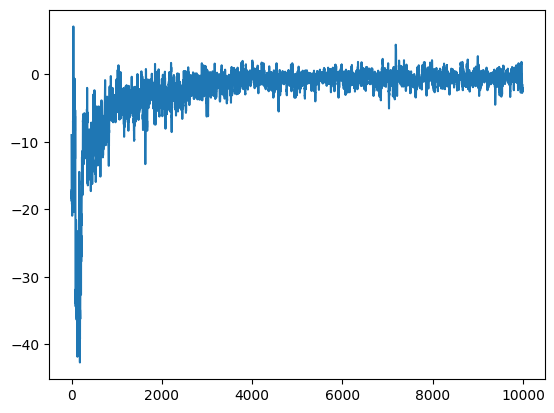

In [10]:
import matplotlib.pyplot as plt
window_size = 10  # 이동 평균의 윈도우 크기
moving_avg = jnp.convolve(qreward_sum.mean(axis=-1), jnp.ones(window_size)/window_size, mode='valid')

plt.plot(moving_avg)

In [11]:

train_state, (env_state, obs, reward, done, log_pi1, log_pi2, a1, a2, left_values) = rollout(carry[0])

(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)


In [12]:
train_state, (env_state, obs, reward, done, log_pi1, log_pi2, a1, a2, left_values) = rollout(train_state)

common_reward = reward['agent_0'] + reward['agent_1']
def calculate_gae(carry, xs):
    last_gae, v_t1, returns = carry
    reward, done, v = xs
    delta = reward + config.gamma * v_t1 - v
    last_gae = delta + config.gamma * config.lamda * last_gae
    returns = reward + config.gamma * returns
    # Fix: Return only a pair (carry, output) instead of (carry, output1, output2)
    return (last_gae * (1-done), v * (1-done), returns * (1-done)), (last_gae, returns)

def get_gae(common_reward, done, left_values):
    _, outputs = jax.lax.scan(calculate_gae, (jnp.array([0.0]), (1-done[-1]) * left_values[-1], (1-done[-1]) * left_values[-1]), (common_reward[::-1], done[::-1], left_values[::-1]))
    gae, returns = outputs
    return -gae[::-1], returns

gae, returns = jax.vmap(get_gae, in_axes=(1, 1, 1))(common_reward, done, left_values)

(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)


In [13]:
def onestep_rollout(train_state):

    key = train_state.key
        
    pi1, pi1_optimizer = get_model(train_state.pi1_state)
    pi2, pi2_optimizer = get_model(train_state.pi2_state)
    value, value_optimizer = get_model(train_state.value_state)

    key, env_reset_key = jax.random.split(key, 2)
    def rollout_(carry, _):
        (env_state, obs, key) = carry
        key1, key2, key3, key4, env_reset_key, key = jax.random.split(key, 6)
        a1, log_pi1 = sample_action(pi1, obs['agent_0'], key1)
        a2, log_pi2 = sample_action(pi2, obs['agent_1'], key2)
        a3, log_pi3 = sample_action(pi2, obs['agent_2'], key3)
        a4, log_pi4 = sample_action(pi1, obs['agent_3'], key4)

        next_obs, next_state, reward, done, info = pong_env.step(None, env_state, {
            'agent_0': a1[None],
            'agent_1': a2[None],
            'agent_2': a3[None],
            'agent_3': a4[None]
        }, config)

        init_obs, init_state = pong_env.reset(env_reset_key)

        is_reset = done | (info['timestep'] > config.episode_length)
        next_obs = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_obs, next_obs)
        next_state_ = jax.tree.map(lambda x, y : jnp.where(is_reset, x, y), init_state, next_state)

        return (next_state_, next_obs, key), (env_state,obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4)
    
    obs, state = pong_env.reset(env_reset_key)

    (env_state, _, key), (env_state, obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4) = jax.lax.scan(rollout_, (state, obs, key), None, config.n_rollout)
    left_values = value(obs['agent_0'])
    right_values = value(obs['agent_3'])
    train_state = train_state._replace(key = key)
    return train_state, (env_state, obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4, left_values, right_values)

In [14]:
config.n_rollout = 5000

In [15]:
train_state, (env_state, obs, reward, done, log_pi1, log_pi2, log_pi3, log_pi4, a1, a2, a3, a4, left_values, right_values) = onestep_rollout(carry[0])

(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)
(2,)


In [ ]:
nnx.log_softmax(pi1(obs['agent_0']), axis=-1)

Array([[-0.7215464 , -0.6655322 ],
       [-0.72170764, -0.6653799 ],
       [-0.72271734, -0.6644264 ],
       ...,
       [-0.7398627 , -0.6485171 ],
       [-0.74027115, -0.64814436],
       [-0.74067247, -0.6477785 ]], dtype=float32)

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from pong import Ball, Paddle, GoalLine, StaticBox

def visualize_frame(objects, ax, frame_num=None):
    """현재 프레임의 모든 물체를 시각화합니다."""
    ax.clear()
    ax.set_xlim(-5, 5)
    ax.set_ylim(-3, 3)
    ax.set_aspect('equal')
    
    # 현재 프레임 번호와 점수 표시
    title_text = f"Frame: {frame_num}"
    ax.set_title(title_text)
    
    for obj in objects.values():
        if isinstance(obj, Ball):
            # 공 그리기 - turn에 따라 색상 다르게
            ball_color = 'red' if obj.turn == 0 else 'blue'
            circle = plt.Circle(
                (obj.transform.position[0], obj.transform.position[1]),
                obj.collider.radius,
                color=ball_color,
                fill=True
            )
            ax.add_patch(circle)
        elif isinstance(obj, Paddle):
            # 패들 그리기 - turn에 따라 색상 다르게
            paddle_color = 'red' if obj.turn == 0 else 'blue'
            half_width = obj.collider.width / 2
            half_height = obj.collider.height / 2
            x = obj.transform.position[0] - half_width
            y = obj.transform.position[1] - half_height
            
            rectangle = patches.Rectangle(
                (x, y),
                obj.collider.width,
                obj.collider.height,
                color=paddle_color,
                fill=True
            )
            ax.add_patch(rectangle)
        elif isinstance(obj, GoalLine):
            # 골라인 그리기 - 팀에 따라 색상 다르게
            goal_color = 'purple' if obj.team == 0 else 'green'
            half_width = obj.collider.width / 2
            half_height = obj.collider.height / 2
            x = obj.transform.position[0] - half_width
            y = obj.transform.position[1] - half_height
            
            rectangle = patches.Rectangle(
                (x, y),
                obj.collider.width,
                obj.collider.height,
                color=goal_color,
                fill=True,
                alpha=0.7
            )
            ax.add_patch(rectangle)
            ax.text(obj.transform.position[0], obj.transform.position[1], f'Score: {obj.score}', ha='center', va='center', color='white', fontweight='bold')
        elif isinstance(obj, StaticBox):
            # 일반 벽 그리기
            half_width = obj.collider.width / 2
            half_height = obj.collider.height / 2
            x = obj.transform.position[0] - half_width
            y = obj.transform.position[1] - half_height
            
            rectangle = patches.Rectangle(
                (x, y),
                obj.collider.width,
                obj.collider.height,
                color='gray',
                fill=True
            )
            ax.add_patch(rectangle)
        
    return ax.patches

def create_animation(history, interval=50, save_gif=False, filename='simulation.gif', frame_skip=1):
    """시뮬레이션 결과의 애니메이션을 생성합니다."""
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # 프레임 스킵 적용
    total_frames = len(history['ball'].transform.position)
    frames_to_show = range(0, total_frames, frame_skip)
    
    def update(frame_idx):
        frame = frames_to_show[frame_idx]
        return visualize_frame(jax.tree.map(lambda x: x[frame], history), ax, frame_num=frame)
    
    ani = FuncAnimation(
        fig, 
        update, 
        frames=len(frames_to_show),
        interval=interval,
        blit=True
    )
    
    # GIF로 저장
    if save_gif:
        ani.save(filename, writer='pillow', fps=1000//interval)
        print(f"Animation saved as {filename}")
    
    plt.close()  # 정적 그림 표시 방지
    return HTML(ani.to_jshtml())

def save_animation_as_gif(history, Box, filename='simulation.gif', interval=50, frame_skip=1):
    """시뮬레이션 결과를 GIF 파일로 저장합니다."""
    return create_animation(history, interval=interval, save_gif=True, filename=filename, frame_skip=frame_skip)

In [17]:
# 애니메이션 생성 및 표시
import numpy as np
numpy_env_state = jax.tree_util.tree_map(lambda x: np.array(x), env_state)
animation = create_animation(numpy_env_state, interval=10, save_gif=True, filename='simulation.gif', frame_skip=10)

Animation saved as simulation.gif
